In [1]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
import numpy as np
import scanpy as sc
import anndata
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
import pickle
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages
import scritmo as sr
from scritmo import w, rh
from scipy.stats import circmean, circstd, circvar
from scritmo import (
    compute_posterior_statistics,
    circular_deviation,
    optimal_shift,
)

from scritmo import (
    compute_posterior_statistics,
    circular_deviation,
)
from scipy.stats import vonmises
import pickle
import scritmo
import scritmo.ml


%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [2]:
os.getcwd()

'/mnt/workspace_dierickx/kcui/18_CR_singlecell/18data/CLOCK_outputs_runs/Phase'

In [3]:
adata = sc.read_h5ad("/mnt/workspace_dierickx/kcui/18_CR_singlecell/18data/1.rawdata/obj_ctqc_RAWcounts_from_all_filtered_feature_bc_matrix.h5ad")

In [4]:
adata.obs["celltype_v2"]   # 或 celltype_v1 / celltype_v2
remove_ct = [
    "Multiciliated epithelial cell",
    "Club cell"
]

adata = adata[~adata.obs["celltype_v2"].isin(remove_ct)].copy()

In [5]:
import pandas as pd

remove_ct = [
    "Multiciliated epithelial cell",
    "Club cell"
]

# 1. 过滤细胞（counts + meta 全部一起过滤）
adata_clean = adata[~adata.obs["celltype_v2"].isin(remove_ct)].copy()

# 2. 清理 category（非常重要，不然 unique() 还会显示旧类型）
if isinstance(adata_clean.obs["celltype_v2"].dtype, pd.CategoricalDtype):
    adata_clean.obs["celltype_v2"] = (
        adata_clean.obs["celltype_v2"]
        .cat.remove_unused_categories()
    )

# 3. 检查一下
print("Remaining celltypes:")
print(sorted(adata_clean.obs["celltype_v2"].unique()))
print("n cells:", adata_clean.n_obs)

# 4. 保存
out_path = "/mnt/workspace_dierickx/kcui/18_CR_singlecell/18data/adata_no_bad_celltypes.h5ad"
adata_clean.write_h5ad(out_path)

print("Saved:", out_path)

Remaining celltypes:
['Adipocytes', 'B cells', 'Cardiac fibroblasts', 'Cardiomyocytes', 'Endocardial cells', 'Endothelial cells', 'Epithelial cells', 'Lymphatic endothelial cells', 'Macrophages', 'Neuronal cells', 'Neutrophils', 'Pericytes', 'Smooth muscle cells', 'T cells']
n cells: 188656
Saved: /mnt/workspace_dierickx/kcui/18_CR_singlecell/18data/adata_no_bad_celltypes.h5ad


In [6]:
adata.layers["spliced"] = adata.X.copy()

In [7]:
zts = adata.obs["ZT"].astype(str)
zts = np.array([int(zt.split("ZT")[-1]) % 24 for zt in zts])
adata.obs["ZT"] = zts
adata.obs["ZTmod"] = zts

In [8]:
celltypes = adata.obs.celltype_v2.values
celltypes_u = np.unique(celltypes)
celltypes_u

array(['Adipocytes', 'B cells', 'Cardiac fibroblasts', 'Cardiomyocytes',
       'Endocardial cells', 'Endothelial cells', 'Epithelial cells',
       'Lymphatic endothelial cells', 'Macrophages', 'Neuronal cells',
       'Neutrophils', 'Pericytes', 'Smooth muscle cells', 'T cells'],
      dtype=object)

In [9]:
ccg = np.array([
    "Arntl", "Npas2",
    "Per1", "Per2", "Per3",
    "Cry1", "Cry2",
    "Nr1d1", "Nr1d2",
    "Dbp", "Tef", "Hlf",
    "Nfil3"
])
ccg = np.intersect1d(ccg, adata.var_names)

In [10]:
ccg

array(['Arntl', 'Cry1', 'Cry2', 'Dbp', 'Hlf', 'Nfil3', 'Npas2', 'Nr1d1',
       'Nr1d2', 'Per1', 'Per2', 'Per3', 'Tef'], dtype=object)

In [11]:
circadian_counts = adata[:, ccg].layers["spliced"].sum(1)
circadian_counts = np.array(circadian_counts)
adata.obs["ccounts"] = circadian_counts
adata.obs["counts"] = adata.layers["spliced"].sum(1).A1

mask0 = (circadian_counts < 1).squeeze()
print(f"Number of cells with 0 circadian counts: {mask0.sum()} out of {adata.shape[0]}")
print(f"Median circadian counts: {np.median(circadian_counts)}")

# adata.layers["s_norm1"] = adata.layers["s_norm"] / 1e4
counts = np.array(adata.layers["spliced"].sum(1)).flatten()

celltype = adata.obs["celltype_v2"].values
# ctu = np.unique(celltype)
circadian_counts = adata[:, ccg].layers["spliced"].sum(1)
circadian_counts = np.array(circadian_counts)
time = adata.obs["ZT"].astype(float)
time_mod = adata.obs["ZT"].astype(float) % 24
true_phase = adata.obs.ZTmod.values.astype(float) * w

Number of cells with 0 circadian counts: 38626 out of 188656
Median circadian counts: 2.0


In [12]:
print("ZT unique:", sorted(adata.obs["ZT"].unique())[:20])
print("ZTmod unique:", sorted(adata.obs["ZTmod"].unique()))

ZT unique: [np.int64(2), np.int64(6), np.int64(10), np.int64(14), np.int64(18), np.int64(22)]
ZTmod unique: [np.int64(2), np.int64(6), np.int64(10), np.int64(14), np.int64(18), np.int64(22)]


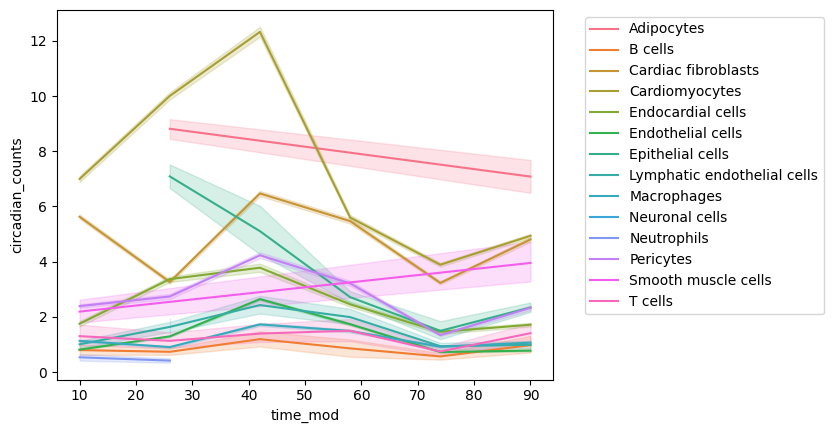

In [13]:
#create df with all those info
df_counts = pd.DataFrame(celltypes, columns=["celltype_v2"])
df_counts["circadian_counts"] = circadian_counts
df_counts["total_counts"] = counts
df_counts["pct_circadian"] = (
    df_counts["circadian_counts"] / df_counts["total_counts"] * 100
)
df_counts["time_mod"] = time_mod.values
df_counts["time_mod"] = df_counts["time_mod"] * 4 + 2
# now plot for each celltype have time_mod vs circadian_counts,
# legend outside
sns.lineplot(data=df_counts, x="time_mod", y="circadian_counts", hue="celltype_v2")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

In [14]:
print(sorted(adata.obs["ZTmod"].unique()))

[np.int64(2), np.int64(6), np.int64(10), np.int64(14), np.int64(18), np.int64(22)]


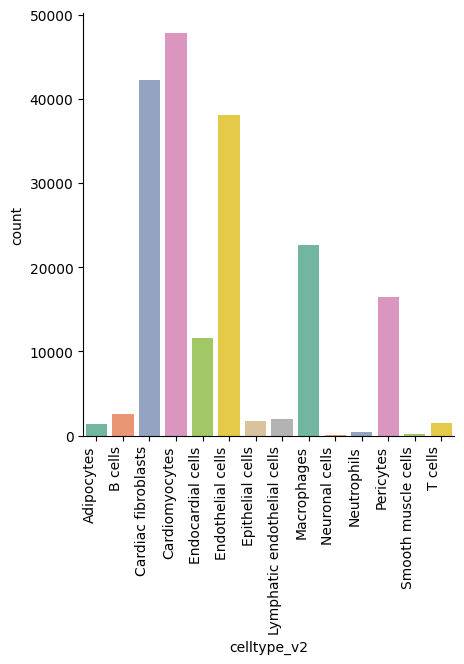

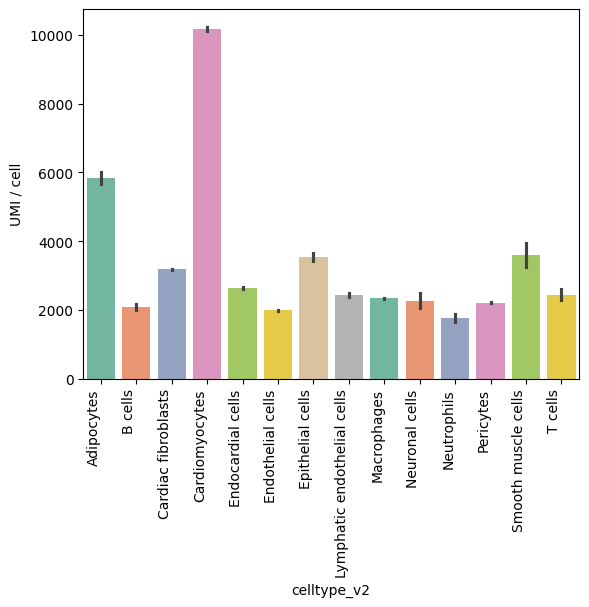

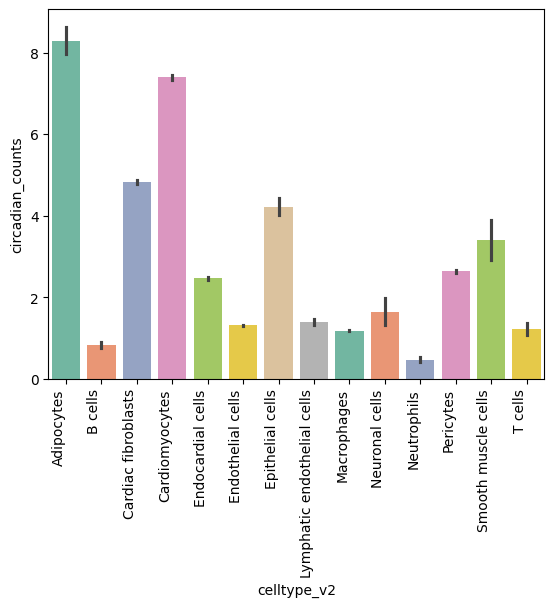

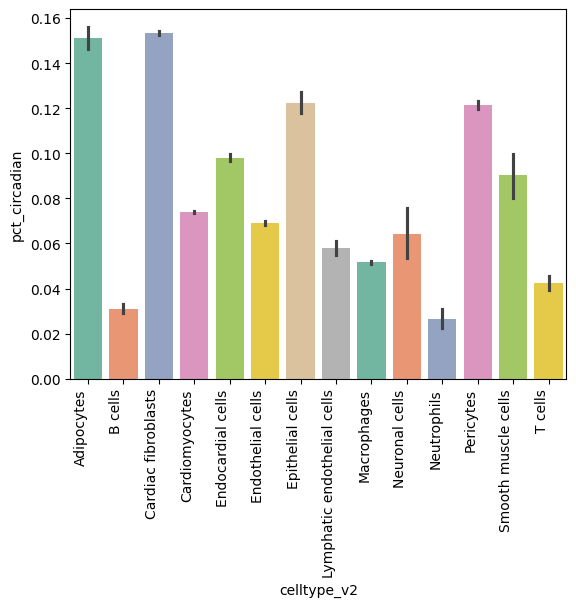

In [15]:
named_palette = "Set2"  # Example of a named palette
# make figure a bit wide
ax = sns.catplot(
    data=df_counts,
    x="celltype_v2",
    # hue="organ",
    palette=named_palette,
    kind="count",
)
# ticks rotation
plt.xticks(rotation=90, ha="right")
plt.show()

# 2. Use the palette in your first plot
ax = sns.barplot(
    data=df_counts,
    x="celltype_v2",
    y="total_counts",
    # hue="organ",
    palette=named_palette,
)
# ticks rotation
plt.xticks(rotation=90, ha="right")
plt.ylabel("UMI / cell")
plt.show()

ax = sns.barplot(
    data=df_counts,
    x="celltype_v2",
    y="circadian_counts",
    # hue="organ",
    palette=named_palette,
)
# ticks rotation
plt.xticks(rotation=90, ha="right")
plt.show()

ax = sns.barplot(
    data=df_counts,
    x="celltype_v2",
    y="pct_circadian",
    # hue="organ",
    palette=named_palette,
)
# ticks rotation
plt.xticks(rotation=90, ha="right")
plt.show()

In [18]:
sizes = adata.obs.groupby(["celltype_v2", "ZTmod"]).size()
empty_sets = sizes[sizes == 0]
empty_sets_df = empty_sets.reset_index()
empty_sets_df.columns = ["celltype_v2", "ZTmod", "count"]
bad_celltypes = list(empty_sets_df["celltype_v2"].unique())
non_bad_celltypes = [ct for ct in celltypes_u if ct not in bad_celltypes]
non_bad_celltypes

['B cells',
 'Cardiac fibroblasts',
 'Cardiomyocytes',
 'Endocardial cells',
 'Endothelial cells',
 'Lymphatic endothelial cells',
 'Macrophages',
 'Pericytes',
 'T cells']

In [19]:
bad_celltypes

['Adipocytes',
 'Epithelial cells',
 'Neuronal cells',
 'Neutrophils',
 'Smooth muscle cells']

In [20]:
true_phase = adata.obs.ZTmod.values * 2 * np.pi / 24

In [21]:
true_phase

array([0.52359878, 0.52359878, 0.52359878, ..., 5.75958653, 5.75958653,
       5.75958653], shape=(188656,))

In [22]:
celltype_counts = df_counts["celltype_v2"].value_counts()
celltypes_over_5k = celltype_counts[celltype_counts > 5000].index.tolist()
print(celltypes_over_5k)

['Cardiomyocytes', 'Cardiac fibroblasts', 'Endothelial cells', 'Macrophages', 'Pericytes', 'Endocardial cells']


In [49]:
param_path = "/mnt/workspace_dierickx/kcui/18_CR_singlecell/18data/CLOCK_outputs_runs/Phase/"

# fit genomewise all celltypes
par_all = {}

for ct in non_bad_celltypes:
    mask = adata.obs["celltype_v2"] == ct
    print(f"fitting celltype: {ct}")
    par = sr.glm_gene_fit(
        adata[mask, :],
        phases=true_phase[mask],
        genes=None,
        pseudobulk_by=["sample", "ZT"],
    )
    par_all[ct] = par

import pickle

# save par_all to pickle
with open(param_path + "params_g_PB.pkl", "wb") as f:
    pickle.dump(par_all, f)

PB = True
if PB:
    filename = param_path + "params_g_PB.pkl"
else:
    filename = param_path + "params_g.pkl"

with open(filename, "rb") as f:
    par_all = pickle.load(f)


fitting celltype: B cells
Running in parallel on -1 jobs.


Fitting genes (parallel): 100%|████| 32286/32286 [00:14<00:00, 2249.52it/s]


fitting celltype: Cardiac fibroblasts
Running in parallel on -1 jobs.


Fitting genes (parallel): 100%|███| 32286/32286 [00:02<00:00, 12667.41it/s]


fitting celltype: Cardiomyocytes
Running in parallel on -1 jobs.


...

fitting celltype: Pericytes
Running in parallel on -1 jobs.


Fitting genes (parallel): 100%|███| 32286/32286 [00:02<00:00, 13808.70it/s]


fitting celltype: T cells
Running in parallel on -1 jobs.


Fitting genes (parallel): 100%|███| 32286/32286 [00:02<00:00, 12971.44it/s]


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/workspace_dierickx/kcui/18_CR_singlecell/18data/CLOCK_outputs_runs/Phase/params_g.pkl'

B cells, N genes: 11736
Cardiac fibroblasts, N genes: 11874
Cardiomyocytes, N genes: 10555
Endocardial cells, N genes: 11678
Endothelial cells, N genes: 11466
Lymphatic endothelial cells, N genes: 11676
Macrophages, N genes: 11592
Pericytes, N genes: 11521
T cells, N genes: 12024


Text(0.5, 1.0, 'PSEUDOBULK = True')

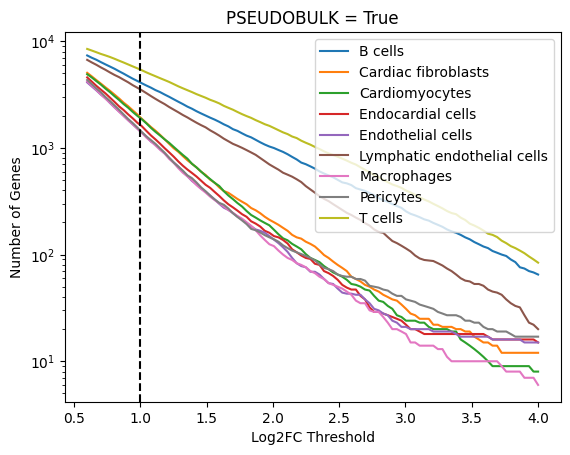

In [24]:
par_all_filtered = {}
for i, ct in enumerate(non_bad_celltypes):

    name = ct
    par = par_all[ct]
    par = par[par.log10_mean > -5.4]
    par_all_filtered[ct] = par
    n_genes = par.shape[0]
    print(f"{name}, N genes: {n_genes}")

    df_int_hist = pd.DataFrame()
    tr_vec = np.linspace(0.6, 4, 100)
    df_int_hist["Threshold"] = tr_vec
    int_hist = sr.reversed_integrated_histo(par["log2fc"], tr_vec)

    plt.plot(tr_vec, int_hist, label=name)

plt.xlabel("Log2FC Threshold")
plt.ylabel("Number of Genes")
plt.yscale("log")
plt.axvline(x=1, color="k", linestyle="--")
plt.legend()
plt.title(f"PSEUDOBULK = {PB}")

# plt.savefig(plot_dict + "MEGA_num_genes_vs_log2fc_threshold.pdf")

In [25]:
pb = sr.pseudobulk(
    adata, groupby_obs_list=["sample", "celltype_v2"], keep_obs=["ZTmod"]
)


pb_phase = pb.obs.ZTmod * w
pb.layers["norm1"] = pb.layers["sum"] / pb.layers["sum"].sum(1).reshape(-1, 1)

In [26]:
par

,a_0,a_1,b_1,disp,BIC,pvalue,r2,pvalue_correctedBH,phase,amp,log2fc,log10_mean
gene,,,,,,,,,,,,
Rp1,-12.120476,-0.106757,-1.124266,0.1,-5.607809,3.785819e-03,0.192702,3.830898e-02,4.618141,1.129323,3.258538,-5.263856
Mrpl15,-10.128290,-0.347889,0.257886,0.1,-0.907805,3.969654e-02,0.076856,1.529105e-01,2.500708,0.433047,1.249510,-4.398661
Lypla1,-9.462855,0.302082,-0.047259,0.1,1.457213,1.295119e-01,0.042420,2.962467e-01,6.126106,0.305756,0.882224,-4.109666
Tcea1,-9.429311,-0.062508,-0.178686,0.1,3.838658,4.260239e-01,0.017627,5.942462e-01,4.373097,0.189303,0.546212,-4.095098
Atp6v1h,-9.530685,0.056305,0.152993,0.1,4.279353,5.310430e-01,0.013515,6.838648e-01,1.218938,0.163024,0.470389,-4.139124
...,...,...,...,...,...,...,...,...,...,...,...,...
mt-Cytb,-6.892882,-0.490610,-0.549316,0.1,-39.608498,1.566764e-10,0.206183,4.531235e-08,3.983539,0.736510,2.125117,-2.993541
CAAA01118383.1,-10.023282,-0.452134,0.015160,0.1,-1.207221,3.417711e-02,0.075401,1.414985e-01,3.110177,0.452387,1.305313,-4.353056
Vamp7,-11.583446,-0.899376,-0.186902,0.1,-5.150090,4.759399e-03,0.165401,4.475133e-02,3.348938,0.918589,2.650487,-5.030627


Percentage of par.pvalue_correctedBH == 0: 6.45%


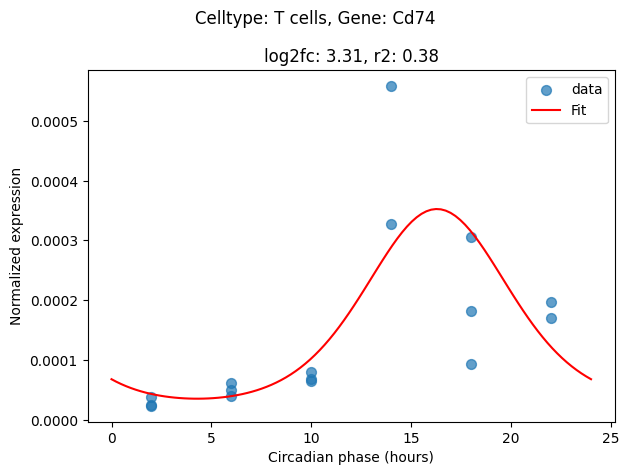

In [27]:
ct = "T cells"

par = par_all[ct]
par = par.quick_filtering(min_mean=-12, min_pval=0.00001)
percent_zero = (par.pvalue_correctedBH == 0).mean() * 100
print(f"Percentage of par.pvalue_correctedBH == 0: {percent_zero:.2f}%")
ccg_ = np.intersect1d(par.index, ccg)
# print(par.loc[ccg_, "r2"])

# g = "Dbp"
g = np.random.choice(par.index)

mask = pb.obs["celltype_v2"] == ct

sr.plot_circadian_data_and_fit(
    pb[mask],
    phis=pb_phase[mask],
    g=g,
    layer="norm1",
    params_g=par,
    s=50,
    # title=
)
plt.suptitle(f"Celltype: {ct}, Gene: {g}")
plt.title(f"log2fc: {par.loc[g,'log2fc']:.2f}, r2: {par.loc[g,'r2']:.2f}")
plt.tight_layout()
plt.show()

In [28]:
# aggreation to find out which celltypes have empty pseudbulk sets
df_groups = pb.obs.groupby(["celltype_v2", "ZTmod"]).size()
df_groups = df_groups.reset_index()
df_groups_ = df_groups.groupby("celltype_v2")[0].sum()

good_pb_celltypes = df_groups_.index[df_groups_.values == 18]
good_pb_celltypes

CategoricalIndex(['Cardiac fibroblasts', 'Cardiomyocytes', 'Endocardial cells',
                  'Endothelial cells', 'Lymphatic endothelial cells',
                  'Macrophages', 'Pericytes'],
                 categories=['Adipocytes', 'B cells', 'Cardiac fibroblasts', 'Cardiomyocytes', ..., 'Neutrophils', 'Pericytes', 'Smooth muscle cells', 'T cells'], ordered=False, dtype='category', name='celltype_v2')

In [30]:
pars_ccg = {}

for i, ct in enumerate(non_bad_celltypes):

    par = par_all[ct]
    ccg_ = np.intersect1d(par.index, ccg)
    par = par.loc[ccg_]

In [31]:
par

,a_0,a_1,b_1,disp,BIC,pvalue,r2,pvalue_correctedBH,phase,amp,log2fc,log10_mean
gene,,,,,,,,,,,,
Arntl,-9.229826,0.298400,-0.278282,0.1,-3.219881,1.249372e-02,0.082298,7.664210e-02,5.535486,0.408022,1.177303,-4.008462
Cry1,-10.147780,0.020453,-0.352321,0.1,1.204948,1.141645e-01,0.053049,2.718210e-01,4.768938,0.352913,1.018293,-4.407125
Cry2,-10.639489,0.274592,-0.083215,0.1,3.577443,3.738625e-01,0.027128,5.478245e-01,5.987876,0.286924,0.827888,-4.620671
Dbp,-10.719670,-1.543709,0.243792,0.1,-52.006245,3.183009e-13,0.446386,1.783579e-10,2.984513,1.562841,4.509406,-4.655493
Hlf,-10.715567,0.064205,-0.470158,0.1,-0.180105,5.711770e-02,0.079169,1.938262e-01,4.850619,0.474521,1.369177,-4.653712
Nfil3,-11.765828,0.111649,0.011242,0.1,5.402677,9.312289e-01,0.003006,9.598129e-01,0.100531,0.112214,0.323780,-5.109834
Npas2,-10.457157,1.211588,-0.181532,0.1,-37.770839,3.926870e-10,0.320103,1.020474e-07,6.132389,1.225109,3.534918,-4.541486
Nr1d1,-11.083773,-0.488298,0.034777,0.1,1.240966,1.162391e-01,0.060729,2.756990e-01,3.072478,0.489534,1.412495,-4.813622
Nr1d2,-9.874866,-0.325334,0.759782,0.1,-19.513267,3.619327e-06,0.222305,2.192505e-04,1.972920,0.826503,2.384782,-4.288600


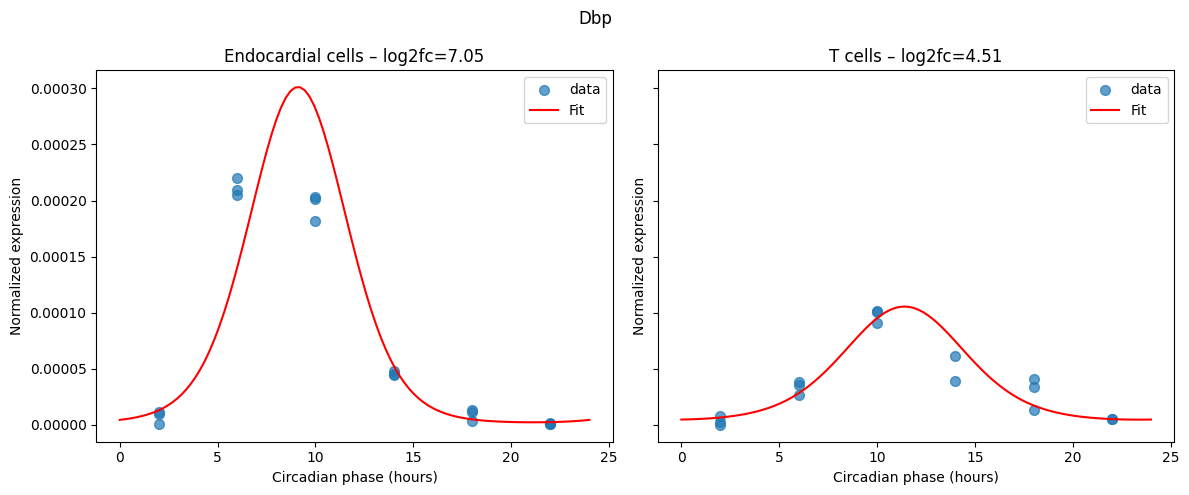

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

g = "Dbp"

for ax, ct in zip(axes, ["Endocardial cells", "T cells"]):
    mask = pb.obs["celltype_v2"] == ct
    par = par_all[ct]
    sr.plot_circadian_data_and_fit(
        pb[mask], phis=pb_phase[mask], g=g, layer="norm1", params_g=par, s=50, ax=ax
    )
    ax.set_title(ct + f" – log2fc={par.loc[g, 'log2fc']:.2f}")


plt.suptitle(g)
plt.tight_layout()
plt.show()

In [33]:
par_all.keys()

par_good_dict = {key: par_all_filtered[key] for key in non_bad_celltypes}

for key in par_good_dict.keys():
    par = par_good_dict[key]
    par["celltype_v2"] = key
    par_good_dict[key] = par

par_concat = pd.concat(par_good_dict.values(), axis=0)
par_concat.reset_index(inplace=True)

# sns.jointplot(
#     data=par_concat,
#     x="log2fc",
#     y="r2",
#     hue="celltype",
#     alpha=0.7,
#     s=50,
#     palette="Set2",
# )

/tmp/ipykernel_158258/4107461393.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  par["celltype_v2"] = key
/tmp/ipykernel_158258/4107461393.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  par["celltype_v2"] = key
/tmp/ipykernel_158258/4107461393.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.h

In [34]:
par_concat

,gene,a_0,a_1,b_1,disp,BIC,pvalue,r2,pvalue_correctedBH,phase,amp,log2fc,log10_mean,celltype_v2
0,Rp1,-12.124676,-0.676013,-0.016951,0.1,1.452283,1.215935e-01,0.077582,3.226992e-01,3.166725,0.676225,1.951173,-5.265680,B cells
1,Mrpl15,-10.592634,0.297793,0.389727,0.1,-1.143121,3.321432e-02,0.075409,1.725985e-01,0.917345,0.490477,1.415219,-4.600322,B cells
2,Lypla1,-9.521281,-0.083189,-0.002524,0.1,5.291338,8.289922e-01,0.003478,9.073493e-01,3.173009,0.083227,0.240143,-4.135040,B cells
3,Tcea1,-9.228502,-0.100409,-0.035743,0.1,5.055821,7.369003e-01,0.005426,8.512771e-01,3.480885,0.106581,0.307527,-4.007887,B cells
4,Atp6v1h,-9.694840,-0.041207,0.418258,0.1,-2.795341,1.453953e-02,0.074393,1.043432e-01,1.671327,0.420282,1.212678,-4.210415,B cells
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104117,mt-Cytb,-6.892882,-0.490610,-0.549316,0.1,-39.608498,1.566764e-10,0.206183,4.531235e-08,3.983539,0.736510,2.125117,-2.993541,T cells
104118,CAAA01118383.1,-10.023282,-0.452134,0.015160,0.1,-1.207221,3.417711e-02,0.075401,1.414985e-01,3.110177,0.452387,1.305313,-4.353056,T cells
104119,Vamp7,-11.583446,-0.899376,-0.186902,0.1,-5.150090,4.759399e-03,0.165401,4.475133e-02,3.348938,0.918589,2.650487,-5.030627,T cells
104120,Tmlhe,-9.755759,0.026458,0.116472,0.1,4.993587,7.589684e-01,0.005583,8.501945e-01,1.344602,0.119438,0.344627,-4.236872,T cells


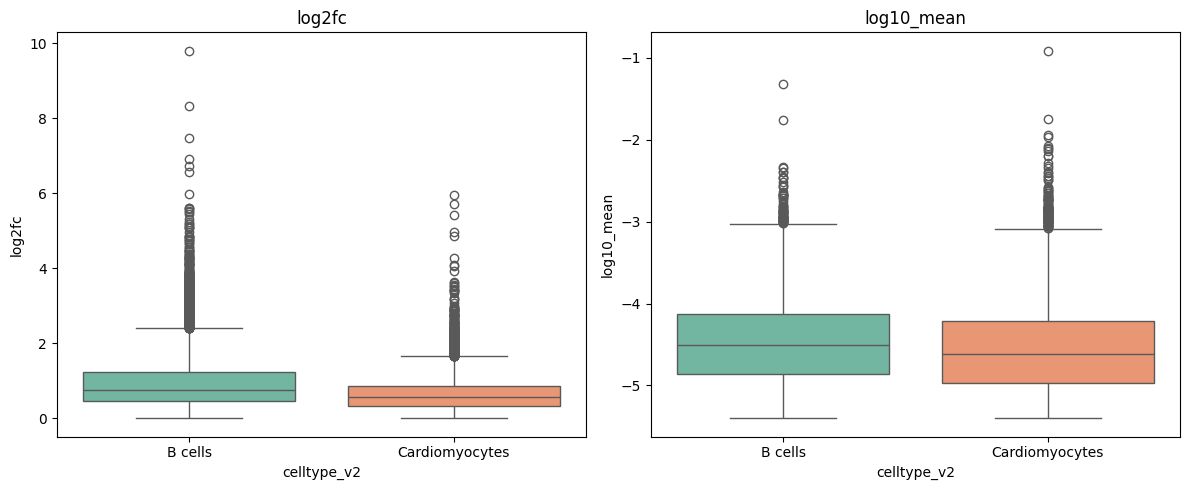

In [35]:
ct_to_plot = ["B cells", "Cardiomyocytes"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(
    data=par_concat[par_concat["celltype_v2"].isin(ct_to_plot)],
    x="celltype_v2",
    y="log2fc",
    hue="celltype_v2",
    palette="Set2",
    ax=axes[0],
)
axes[0].set_title("log2fc")

sns.boxplot(
    data=par_concat[par_concat["celltype_v2"].isin(ct_to_plot)],
    x="celltype_v2",
    y="log10_mean",
    hue="celltype_v2",
    palette="Set2",
    ax=axes[1],
)
axes[1].set_title("log10_mean")

plt.tight_layout()
plt.show()

<Axes: xlabel='log10_mean', ylabel='log2fc'>

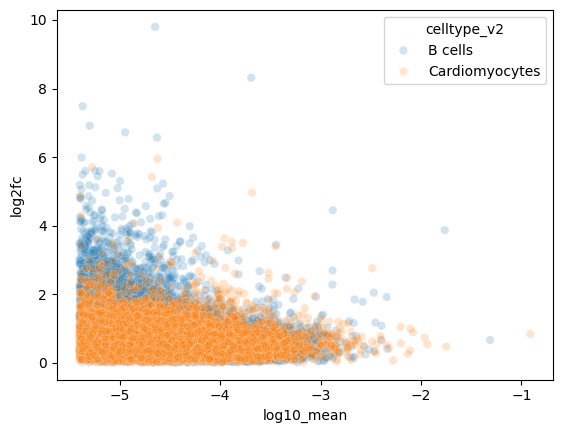

In [36]:
par_plot = par_concat[par_concat["celltype_v2"].isin(ct_to_plot)]

sns.scatterplot(data=par_plot, x="log10_mean", y="log2fc", hue="celltype_v2", alpha=0.2)

# csvd

In [37]:
ct_csvd = non_bad_celltypes

par_all_5k = {ct: par_all[ct].loc for ct in ct_csvd}

# find genes common to all par in par_all_5k
# Fix: actually select the DataFrame for each celltype, not the .loc indexer
par_all_5k = {ct: par_all[ct] for ct in ct_csvd}

common_genes = set.intersection(*(set(par.index) for par in par_all_5k.values()))
common_genes = common_genes & set(ccg)
common_genes = np.array(list(common_genes))


par_csvd = {ct: par_all[ct].loc[common_genes] for ct in ct_csvd}

U, V, S_norm = sr.cSVD_beta(par_csvd)

<PolarAxes: title={'center': 'CSVD'}>

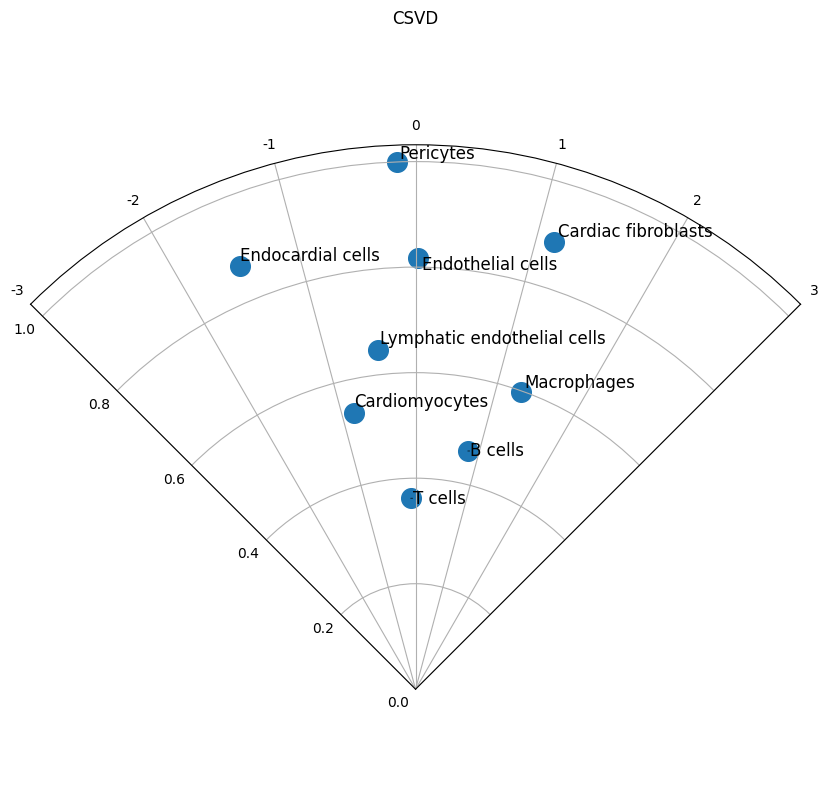

In [38]:
shift_y_csvd = np.angle(V[:, 0])
lambda_y_csvd = np.abs(V[:, 0])

sr.polar_plot_shifts(angle=np.pi / 2, title="CSVD")

plt.scatter(shift_y_csvd, lambda_y_csvd, s=200)
sr.scatter_with_labels(shift_y_csvd, lambda_y_csvd, ct_csvd, fontsize=12)

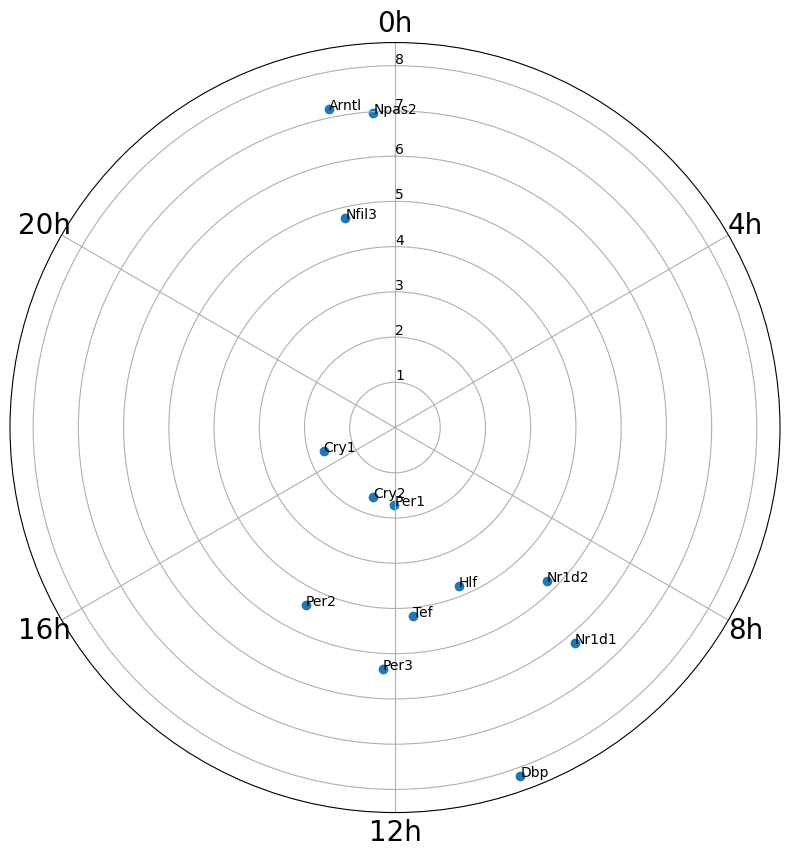

In [39]:
gene_abs = np.abs(U[:, 0])
gene_phase = np.angle(U[:, 0])

sr.polar_plot()
plt.scatter(gene_phase, gene_abs)
# annotate the genes
for i, g in enumerate(common_genes):
    plt.text(gene_phase[i], gene_abs[i], g)

# investigating high amps in Bcells

In [40]:
high_cts = ["T cells", "B cells", "Lymphatic endothelial cells"]

In [41]:
par_concat

,gene,a_0,a_1,b_1,disp,BIC,pvalue,r2,pvalue_correctedBH,phase,amp,log2fc,log10_mean,celltype_v2
0,Rp1,-12.124676,-0.676013,-0.016951,0.1,1.452283,1.215935e-01,0.077582,3.226992e-01,3.166725,0.676225,1.951173,-5.265680,B cells
1,Mrpl15,-10.592634,0.297793,0.389727,0.1,-1.143121,3.321432e-02,0.075409,1.725985e-01,0.917345,0.490477,1.415219,-4.600322,B cells
2,Lypla1,-9.521281,-0.083189,-0.002524,0.1,5.291338,8.289922e-01,0.003478,9.073493e-01,3.173009,0.083227,0.240143,-4.135040,B cells
3,Tcea1,-9.228502,-0.100409,-0.035743,0.1,5.055821,7.369003e-01,0.005426,8.512771e-01,3.480885,0.106581,0.307527,-4.007887,B cells
4,Atp6v1h,-9.694840,-0.041207,0.418258,0.1,-2.795341,1.453953e-02,0.074393,1.043432e-01,1.671327,0.420282,1.212678,-4.210415,B cells
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104117,mt-Cytb,-6.892882,-0.490610,-0.549316,0.1,-39.608498,1.566764e-10,0.206183,4.531235e-08,3.983539,0.736510,2.125117,-2.993541,T cells
104118,CAAA01118383.1,-10.023282,-0.452134,0.015160,0.1,-1.207221,3.417711e-02,0.075401,1.414985e-01,3.110177,0.452387,1.305313,-4.353056,T cells
104119,Vamp7,-11.583446,-0.899376,-0.186902,0.1,-5.150090,4.759399e-03,0.165401,4.475133e-02,3.348938,0.918589,2.650487,-5.030627,T cells
104120,Tmlhe,-9.755759,0.026458,0.116472,0.1,4.993587,7.589684e-01,0.005583,8.501945e-01,1.344602,0.119438,0.344627,-4.236872,T cells


In [42]:
par_concat[par_concat.log2fc > 1.0].to_csv("par_concat.csv")

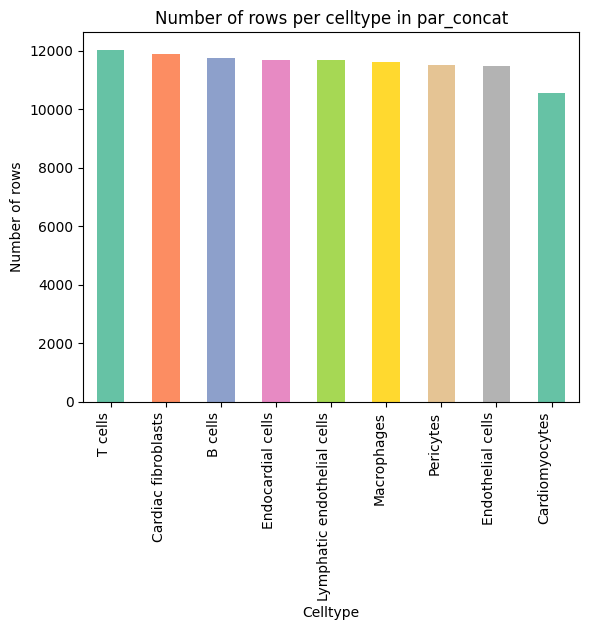

In [43]:
par_concat

celltype_row_counts = par_concat["celltype_v2"].value_counts()
ax = celltype_row_counts.plot(
    kind="bar", color=sns.color_palette(named_palette, len(celltype_row_counts))
)
plt.ylabel("Number of rows")
plt.xlabel("Celltype")
plt.title("Number of rows per celltype in par_concat")
plt.xticks(rotation=90, ha="right")
plt.show()

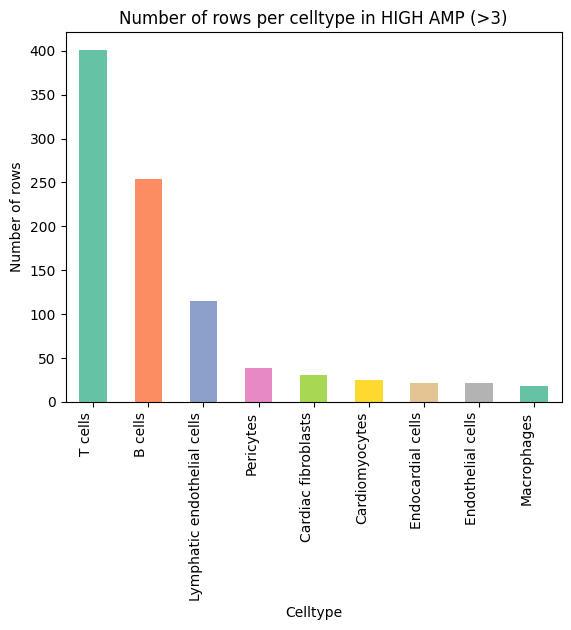

In [44]:
par_conc_high = par_concat[par_concat.log2fc > 3]

celltype_row_counts = par_conc_high["celltype_v2"].value_counts()
ax = celltype_row_counts.plot(
    kind="bar", color=sns.color_palette(named_palette, len(celltype_row_counts))
)
plt.ylabel("Number of rows")
plt.xlabel("Celltype")
plt.title("Number of rows per celltype in HIGH AMP (>3)")
plt.xticks(rotation=90, ha="right")
plt.show()

In [45]:
par_conc_high_immune = par_conc_high[par_conc_high.celltype_v2.isin(high_cts)]
# Find genes present in all 3 high_cts celltypes
genes_per_ct = [
    set(par_conc_high_immune[par_conc_high_immune.celltype_v2 == ct].gene)
    for ct in high_cts
]
common_genes_high_cts = set.intersection(*genes_per_ct)
print(f"Genes present in all high_cts: {len(common_genes_high_cts)}")
print(list(common_genes_high_cts))

Genes present in all high_cts: 8
['Cmss1', 'Gm42418', 'Ahsg', 'Bmper', 'Npas2', 'Dbp', 'Cytl1', 'Lars2']


In [46]:
print(par_conc_high.columns)
print(par_conc_high.head())

Index(['gene', 'a_0', 'a_1', 'b_1', 'disp', 'BIC', 'pvalue', 'r2',
       'pvalue_correctedBH', 'phase', 'amp', 'log2fc', 'log10_mean',
       'celltype_v2'],
      dtype='object')
      gene        a_0       a_1       b_1  disp        BIC        pvalue  \
19   Prex2 -10.308284 -0.950111 -0.600679   0.1 -38.024471  3.255682e-10   
38   Gsta3 -12.316798 -0.831360 -0.831015   0.1  -5.358704  4.035741e-03   
86   Npas2 -11.468932  1.331422 -0.085662   0.1 -25.621941  1.606266e-07   
326  Cdh20 -11.991182 -1.139087  0.007295   0.1  -9.931763  4.101061e-04   
399  Sox13 -11.408359 -0.243149 -1.083353   0.1 -19.964396  2.718551e-06   

           r2  pvalue_correctedBH     phase       amp    log2fc  log10_mean  \
19   0.324387        7.240167e-08  3.707079  1.124065  3.243366   -4.476831   
38   0.196949        5.036626e-02  3.926991  1.175477  3.391710   -5.349117   
86   0.297176        1.796876e-05  6.220353  1.334174  3.849611   -4.980894   
326  0.219398        1.121443e-02  3.135309  1

In [47]:
GENE_COL = "gene"  # <-- 如果不是 gene，就改成你的列名；或者看是否在 index
# 如果基因在 index：
# par_conc_high = par_conc_high.reset_index().rename(columns={"index":"gene"})
genes_by_ct = (
    par_conc_high
    .dropna(subset=["celltype_v2", GENE_COL])
    .groupby("celltype_v2")[GENE_COL]
    .apply(lambda x: sorted(set(map(str, x))))
    .to_dict()
)
# 看每个 celltype 多少基因
for ct, g in genes_by_ct.items():
    print(ct, len(g))


B cells 254
Cardiac fibroblasts 31
Cardiomyocytes 25
Endocardial cells 22
Endothelial cells 21
Lymphatic endothelial cells 115
Macrophages 18
Pericytes 38
T cells 401


In [52]:
true_phase_np = np.array(true_phase, dtype=float)

param_path = "/mnt/workspace_dierickx/kcui/18_CR_singlecell/18data/CLOCK_outputs_runs/Phase/"
os.makedirs(param_path, exist_ok=True)

par_all = {}

for ct in non_bad_celltypes:
    mask = (adata.obs["celltype_v2"] == ct).to_numpy()

    ad_ct = adata[mask, :].copy()
    ph = true_phase_np[mask].reshape(-1)

    print(f"fitting {ct}: cells={ad_ct.n_obs} ALL GENES")

    par = sr.glm_gene_fit(
        ad_ct,
        phases=ph,
        genes=None    
    )

    par_all[ct] = par

out_pkl = os.path.join(param_path, "params_g.pkl")
with open(out_pkl, "wb") as f:
    pickle.dump(par_all, f)

print("✅ saved:", out_pkl)


fitting B cells: cells=2564 ALL GENES
Running in parallel on -1 jobs.


Fitting genes (parallel): 100%|████| 32286/32286 [00:04<00:00, 6773.17it/s]


fitting Cardiac fibroblasts: cells=42221 ALL GENES
Running in parallel on -1 jobs.


Fitting genes (parallel):   5%|▎     | 1536/32286 [00:08<03:15, 157.27it/s]/home/kcui/.conda/envs/scRITMO/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
Fitting genes (parallel): 100%|█████| 32286/32286 [04:25<00:00, 121.77it/s]


fitting Cardiomyocytes: cells=47789 ALL GENES
Running in parallel on -1 jobs.


...

fitting Pericytes: cells=16489 ALL GENES
Running in parallel on -1 jobs.


Fitting genes (parallel): 100%|█████| 32286/32286 [00:59<00:00, 538.84it/s]


fitting T cells: cells=1465 ALL GENES
Running in parallel on -1 jobs.


Fitting genes (parallel): 100%|███| 32286/32286 [00:02<00:00, 11350.15it/s]


✅ saved: /mnt/workspace_dierickx/kcui/18_CR_singlecell/18data/CLOCK_outputs_runs/Phase/params_g.pkl
